# Chapter 15 — Understanding Strategy Risk

Investment strategies are usually built around two exit conditions: take profit,
or cut losses. That structure means the outcome of any single bet is well
modeled as a **binomial process** — a bet either wins or loses. This chapter
asks a sharper question than "what's my portfolio's risk?": given how
frequently I bet, and my precision (win rate), what's the probability that
**the strategy itself** fails to hit its target Sharpe ratio? Strategy risk
is not the same thing as portfolio risk — a low-volatility strategy can still
be very likely to underperform its target if its edge is thin and its
betting frequency is low.

Three parts below:
- **Part A** — symmetric payouts (Sec 15.2): the simplest case, where a win
  and a loss are mirror images of each other.
- **Part B** — asymmetric payouts (Sec 15.3): profit-taking and stop-loss
  levels can differ.
- **Part C** — the probability of strategy failure (Sec 15.4), applied to
  **real data**: Ch3's actual 88 BTC/TUSD triple-barrier bet outcomes.

In [1]:
AFML_ROOT = r'C:\ws\AFML'  # <-- EDIT THIS for your machine

import os, sys
if AFML_ROOT not in sys.path:
    sys.path.insert(0, AFML_ROOT)
sys.path.insert(0, os.path.join(AFML_ROOT, 'ch15', 'strategy_risk'))

INPUT_DATA = os.path.join(AFML_ROOT, 'input_data')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import symmetric as sym
import asymmetric as asym
import algorithm as algo

## Part A — Symmetric payouts (Sec 15.2)

A strategy makes $n$ IID bets per year. Bet $i$ pays $+\pi$ with probability
$p$ (precision), or $-\pi$ with probability $1-p$. Because the payout is
symmetric, $\pi$ cancels out algebraically, and the annualized Sharpe ratio
depends **only** on precision and betting frequency:

$$\theta[p,n] = \frac{2p-1}{2\sqrt{p(1-p)}}\sqrt{n}$$

This is exactly a re-scaled t-value of $p$ under $H_0: p=\tfrac12$ — which is
why even a precision barely above 0.5 can reach a high Sharpe ratio, provided
$n$ is large enough. That's the economic basis for high-frequency trading:
the edge per bet can be tiny if you make enough bets.

Solving for the precision needed to hit a target Sharpe $\theta^*$ at a given
frequency $n$:

$$p = \frac12\left(1+\sqrt{1-\frac{n}{\theta^{*2}+n}}\right)$$

In [2]:
# Book's own worked example: p=.55
p_example = .55
coefficient = sym.sharpe_ratio_symmetric(p_example, n=1)
n_for_theta_2 = (2 / coefficient) ** 2
print(f"p={p_example}: per-sqrt(n) Sharpe coefficient = {coefficient:.4f}  (book: 0.1005)")
print(f"bets/year needed for annualized Sharpe=2: {n_for_theta_2:.1f}  (book: 396)")

p=0.55: per-sqrt(n) Sharpe coefficient = 0.1005  (book: 0.1005)
bets/year needed for annualized Sharpe=2: 396.0  (book: 396)


In [3]:
# Book's other worked example: weekly bets (n=52)
p_weekly = sym.implied_precision_symmetric(n=52, tSR=2)
print(f"Weekly bets (n=52) need precision p={p_weekly:.4f} for Sharpe=2  (book: 0.6336)")

Weekly bets (n=52) need precision p=0.6336 for Sharpe=2  (book: 0.6336)


### Snippet 15.1 — Monte Carlo cross-check

The book's own verification: simulate 1,000,000 $\pm1$ outcomes at $p=.55$ and
confirm `mean/std` matches the closed-form coefficient. Ported to Python 3 and
a seeded `numpy.random.Generator` (book used Python 2's `xrange`/`print` and
the legacy global RNG state) per this project's random_state convention.

In [4]:
rng = np.random.default_rng(2026)
mc_mean, mc_std, mc_sharpe = sym.simulate_symmetric_sharpe(p_example, n_draws=1_000_000, rng=rng)
print(f"Monte Carlo (1e6 draws, seed=2026): mean={mc_mean:.4f}, std={mc_std:.4f}, sharpe={mc_sharpe:.4f}")
print(f"Closed form: {coefficient:.4f}")

Monte Carlo (1e6 draws, seed=2026): mean=0.1003, std=0.9950, sharpe=0.1008
Closed form: 0.1005


**Figure 15.1** — Sharpe ratio vs. precision, for a few betting frequencies (reproduces the book's own figure).

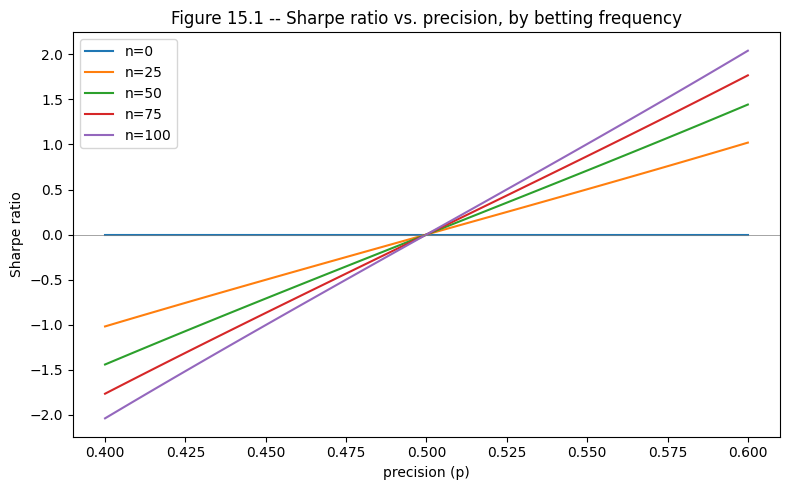

In [5]:
p_grid = np.linspace(0.40, 0.60, 100)
fig, ax = plt.subplots(figsize=(8, 5))
for n in [0, 25, 50, 75, 100]:
    if n == 0:
        theta_grid = np.zeros_like(p_grid)
    else:
        theta_grid = [sym.sharpe_ratio_symmetric(p, n) for p in p_grid]
    ax.plot(p_grid, theta_grid, label=f'n={n}')
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('precision (p)')
ax.set_ylabel('Sharpe ratio')
ax.set_title('Figure 15.1 -- Sharpe ratio vs. precision, by betting frequency')
ax.legend()
fig.tight_layout()
plt.show()

## Part B — Asymmetric payouts (Sec 15.3)

Generalizing: a bet now pays $\pi_+$ with probability $p$, or $\pi_-<\pi_+$
with probability $1-p$ — profit-taking and stop-loss no longer need to be
mirror images:

$$\theta[p,n,\pi_-,\pi_+] = \frac{(\pi_+-\pi_-)p+\pi_-}{(\pi_+-\pi_-)\sqrt{p(1-p)}}\sqrt{n}$$

Solving for the implied precision given a target Sharpe:

$$p = \frac{-b+\sqrt{b^2-4ac}}{2a}, \quad a=(n+\theta^{*2})(\pi_+-\pi_-)^2,\;\;
b=[2n\pi_- - \theta^{*2}(\pi_+-\pi_-)](\pi_+-\pi_-),\;\; c=n\pi_-^2$$

Function names (`binHR`, `binFreq`, `binSR`) are kept exactly as printed in
the book (Snippets 15.3–15.4).

In [6]:
SL, PT, FREQ = -.01, .005, 260  # book's own running example

theta_asym = asym.binSR(SL, PT, FREQ, p=.7)
print(f"sl={SL}, pt={PT}, freq={FREQ}, p=.7 -> theta={theta_asym:.4f}  (book: 1.173)")

p_for_theta_2 = asym.binHR(SL, PT, FREQ, tSR=2)
print(f"Same params, implied precision for theta=2: p={p_for_theta_2:.4f}  (book: .72)")

sl=-0.01, pt=0.005, freq=260, p=.7 -> theta=1.1729  (book: 1.173)
Same params, implied precision for theta=2: p=0.7222  (book: .72)


**The break-even precision.** Setting $\theta^*=0$ gives the precision below
which the strategy has *negative* expected Sharpe — a small drop below it can
wipe out all profits even though the strategy "looks" fine on paper.

In [7]:
p_breakeven = asym.binHR(SL, PT, FREQ, tSR=0)
print(f"Break-even precision: p_theta*=0={p_breakeven:.4f}  (book: 2/3={2/3:.4f})")

Break-even precision: p_theta*=0=0.6667  (book: 2/3=0.6667)


**Figure 15.2** — implied precision heat-map as a function of betting frequency and stop-loss ($\pi_+=0.1$, $\theta^*=1.5$).

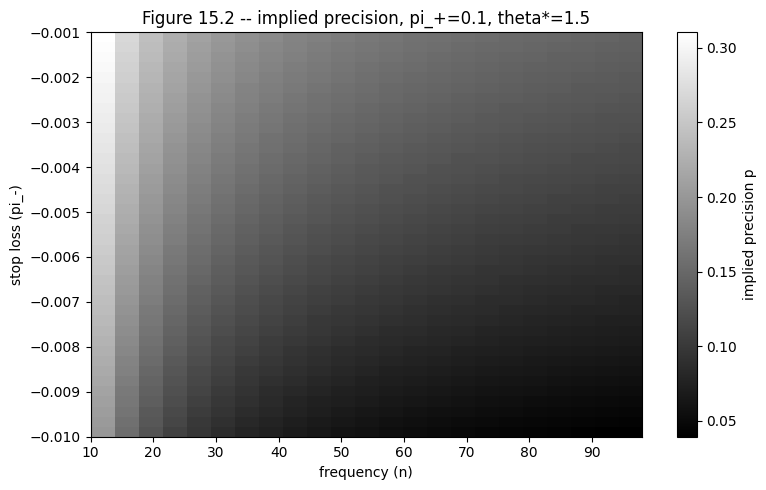

In [8]:
sl_grid = np.linspace(-0.01, -0.001, 40)
freq_grid = np.arange(10, 100, 4)
heat = np.zeros((len(sl_grid), len(freq_grid)))
for i, sl in enumerate(sl_grid):
    for j, freq in enumerate(freq_grid):
        heat[i, j] = asym.binHR(sl, pt=0.1, freq=freq, tSR=1.5)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(heat, aspect='auto', cmap='gray',
                extent=[freq_grid.min(), freq_grid.max(), sl_grid.min(), sl_grid.max()],
                origin='upper')
ax.set_xlabel('frequency (n)')
ax.set_ylabel('stop loss (pi_-)')
ax.set_title('Figure 15.2 -- implied precision, pi_+=0.1, theta*=1.5')
fig.colorbar(im, ax=ax, label='implied precision p')
fig.tight_layout()
plt.show()

## Part C — The probability of strategy failure (Sec 15.4), on REAL data

Given a real series of bet outcomes $\{\pi_t\}$, estimate $\pi_-=E[\pi_t|\pi_t\le0]$,
$\pi_+=E[\pi_t|\pi_t>0]$, and the empirical precision $\bar p$. For a large
bootstrap sample size, the distribution of $p$ can be approximated as
$f[p]\sim N[\bar p,\bar p(1-\bar p)]$, and the strategy's probability of
failure is $P[p<p_{\theta^*}]$ — the area of that Gaussian below the
break-even precision for a target Sharpe $\theta^*$.

**Real data, not synthetic**: this uses Ch3's actual 88 BTC/TUSD
triple-barrier events — real realized returns from real trades, not a
placeholder mixture.

In [9]:
events = pd.read_csv(os.path.join(INPUT_DATA, 'ch03_events.csv'), index_col=0, parse_dates=[0, 1])
ret = events['ret'].values
print(f"Loaded {len(events)} real triple-barrier bet outcomes")

elapsed = events['t1'].max() - events.index.min()
elapsed_years = elapsed.total_seconds() / (365.25 * 24 * 3600)
freq_real = len(events) / elapsed_years
print(f"Elapsed window: {elapsed} = {elapsed_years:.4f} years")
print(f"Annualized frequency n = T/y = {freq_real:.1f} bets/year")

Loaded 88 real triple-barrier bet outcomes
Elapsed window: 29 days 04:09:11.162960 = 0.0799 years
Annualized frequency n = T/y = 1101.8 bets/year


**A genuine caveat, not glossed over:** only ~29 real days of trade data are
available (Ch2's single-month BTC/TUSD tape), so annualizing multiplies the
apparent bet rate by roughly $365.25/29\approx12.6\times$. Treat the
"annualized" figures below as a real result from real data, heavily
extrapolated from a short window — not a full-year track record.

In [10]:
n_pos = (ret > 0).sum()
p_bar = n_pos / len(ret)
r_pos, r_neg = ret[ret > 0].mean(), ret[ret <= 0].mean()
print(f"Realized precision p_bar = {p_bar:.4f} ({n_pos} of {len(events)} bets positive)")
print(f"Mean winning return (pi_+) = {r_pos:.4f}, mean losing return (pi_-) = {r_neg:.4f}")

theta_realized = np.sqrt(freq_real) * ret.mean() / ret.std()
print(f"Realized (empirical) annualized Sharpe on this series: {theta_realized:.4f}")

Realized precision p_bar = 0.5568 (49 of 88 bets positive)
Mean winning return (pi_+) = 0.0337, mean losing return (pi_-) = -0.0325
Realized (empirical) annualized Sharpe on this series: 4.1159


### The LOAD-BEARING fix, in action

The book's printed `probFailure` passes `p*(1-p)` (a **variance** — see the
$N[\bar p,\bar p(1-\bar p)]$ approximation above) as `scipy.stats.norm.cdf`'s
`scale` argument, which scipy documents as a **standard deviation**. Confirmed
as a real printed-snippet bug (same category as Ch5's tuple-assignment issue),
fixed here to pass `sqrt(p*(1-p))` — see `algorithm.py`'s `LOAD-BEARING`
comment for the full writeup.

In [11]:
print(f"{'tSR':>6} {'p_theta*':>10} {'P[fail]':>10}")
for tSR in [0.5, 1.0, 2.0]:
    risk = algo.probFailure(ret, freq_real, tSR)
    thres_p = asym.binHR(r_neg, r_pos, freq_real, tSR)
    print(f"{tSR:>6.1f} {thres_p:>10.4f} {risk:>10.4f}")

   tSR   p_theta*    P[fail]
   0.5     0.4978     0.4527
   1.0     0.5053     0.4587
   2.0     0.5204     0.4707


**Real-data finding:** at every target Sharpe tested here (0.5, 1.0, 2.0),
$P[\text{fail}]\approx0.45$–$0.47$ — far above the book's own "disregard if
>.05" rule of thumb. This corroborates, via an entirely independent method,
the same "no reliable exploitable signal in this feature set/model" finding
already established elsewhere in this pipeline: Ch11's PBO (~0.83), Ch12's
CPCV (all 5 paths negative), Ch13's non-stationary O-U calibration, and
Ch14's DSR (0/5 paths survive). Strategy risk here isn't a quirk of this
chapter's method — it's consistent with everything else this pipeline has
found on this data.

## TDD results

Embedded per project convention, after tests passed.

**SANDBOX CONFIRMED** (Python 3.12.3, pytest 9.1.1, 2026-07-23) — 34 tests
across all three ch15 modules (`symmetric.py`, `asymmetric.py`,
`algorithm.py`), run together since they're interdependent (`asymmetric.binSR`
underlies a symmetric cross-check test; `algorithm.probFailure` calls
`asymmetric.binHR`).

**REAL-MACHINE CONFIRMATION (mlfinlab env) STILL NEEDED** — see README.md.

```
============================= test session starts ==============================
platform linux -- Python 3.12.3, pytest-9.1.1, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /home/claude/afml_work/ch15/strategy_risk
collecting ... collected 34 items

test_algorithm.py::TestProbFailureHandTraced::test_hand_traced_every_step PASSED [  2%]
test_algorithm.py::TestProbFailureHandTraced::test_all_positive_returns PASSED [  5%]
test_algorithm.py::TestProbFailureSeededRegression::test_book_parameters_seeded_regression PASSED [  8%]
test_algorithm.py::TestProbFailureSeededRegression::test_fix_actually_changes_result_vs_literal_book_code PASSED [ 11%]
test_algorithm.py::TestMixGaussians::test_output_length_matches_nObs PASSED [ 14%]
test_algorithm.py::TestMixGaussians::test_reproducible_with_seeded_generator PASSED [ 17%]
test_algorithm.py::TestMixGaussians::test_prob1_one_gives_pure_first_component PASSED [ 20%]
test_asymmetric.py::TestBinSR::test_book_worked_example PASSED           [ 23%]
test_asymmetric.py::TestBinSR::test_reduces_to_symmetric_case PASSED     [ 26%]
test_asymmetric.py::TestBinSR::test_precision_half_gives_expected_value_only_pull PASSED [ 29%]
test_asymmetric.py::TestBinHR::test_book_worked_example_theta_2 PASSED   [ 32%]
test_asymmetric.py::TestBinHR::test_p_theta_star_zero_special_case PASSED [ 35%]
test_asymmetric.py::TestBinHR::test_roundtrip_with_binsr PASSED          [ 38%]
test_asymmetric.py::TestBinHR::test_negative_discriminant_raises PASSED  [ 41%]
test_asymmetric.py::TestBinFreq::test_roundtrip_recovers_book_frequency PASSED [ 44%]
test_asymmetric.py::TestBinFreq::test_roundtrip_with_binsr_general PASSED [ 47%]
test_asymmetric.py::TestBinFreq::test_higher_precision_needs_fewer_bets PASSED [ 50%]
test_asymmetric.py::TestBinFreq::test_extraneous_below_breakeven_returns_none PASSED [ 52%]
test_asymmetric.py::TestBinFreq::test_at_or_above_breakeven_precision_has_valid_solution PASSED [ 55%]
test_symmetric.py::TestSharpeRatioSymmetric::test_book_worked_example_p55 PASSED [ 58%]
test_symmetric.py::TestSharpeRatioSymmetric::test_book_worked_example_396_bets PASSED [ 61%]
test_symmetric.py::TestSharpeRatioSymmetric::test_p_half_gives_zero_sharpe PASSED [ 64%]
test_symmetric.py::TestSharpeRatioSymmetric::test_symmetric_around_half PASSED [ 67%]
test_symmetric.py::TestSharpeRatioSymmetric::test_n_zero_gives_zero_sharpe PASSED [ 70%]
test_symmetric.py::TestSharpeRatioSymmetric::test_p_out_of_range_raises PASSED [ 73%]
test_symmetric.py::TestSharpeRatioSymmetric::test_negative_n_raises PASSED [ 76%]
test_symmetric.py::TestImpliedPrecisionSymmetric::test_book_worked_example_weekly_bets PASSED [ 79%]
test_symmetric.py::TestImpliedPrecisionSymmetric::test_roundtrip_against_sharpe_ratio_symmetric PASSED [ 82%]
test_symmetric.py::TestImpliedPrecisionSymmetric::test_higher_n_needs_lower_precision PASSED [ 85%]
test_symmetric.py::TestImpliedPrecisionSymmetric::test_zero_frequency_zero_target_raises PASSED [ 88%]
test_symmetric.py::TestImpliedPrecisionSymmetric::test_negative_n_raises PASSED [ 91%]
test_symmetric.py::TestSimulateSymmetricSharpe::test_cross_validated_against_closed_form PASSED [ 94%]
test_symmetric.py::TestSimulateSymmetricSharpe::test_reproducible_with_seeded_generator PASSED [ 97%]
test_symmetric.py::TestSimulateSymmetricSharpe::test_p_one_gives_std_zero_and_nan_sharpe PASSED [100%]

=============================== warnings summary ===============================
test_algorithm.py::TestProbFailureHandTraced::test_all_positive_returns

test_algorithm.py::TestProbFailureHandTraced::test_all_positive_returns

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
======================== 34 passed, 2 warnings in 1.07s ========================
```
